In [2]:
%pip install tensorflow

import tensorflow as tf

if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")
    print("Default GPU Device: None")

     |                                | 20 kB 800 kB/s eta 0:05:25  Downloading tensorflow-2.16.2-cp39-cp39-macosx_10_15_x86_64.whl (259.5 MB)
     |████████████████████████████████| 259.5 MB 40 kB/s  eta 0:00:01     |████████████████████▏           | 163.4 MB 6.5 MB/s eta 0:00:15     |████████████████████▏           | 163.4 MB 6.5 MB/s eta 0:00:15
     |████████████████████████████████| 259.5 MB 40 kB/s 
     |████████████████████████████████| 71 kB 1.0 MB/s eta 0:00:011
     |████████████████████████████████| 71 kB 1.0 MB/s eta 0:00:011
     |████████████████████████████████| 2.5 MB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 2.5 MB 6.5 MB/s eta 0:00:01
     |▍                               | 153 kB 6.6 MB/s eta 0:00:02  Downloading grpcio-1.78.0-cp39-cp39-macosx_11_0_universal2.whl (11.8 MB)
     |████████████████████████████████| 11.8 MB 62.8 MB/s eta 0:00:01
     |████████████████████████████████| 11.8 MB 62.8 MB/s 
     |████████████████████████████████| 26.5 MB 

2026-03-03 05:46:41.320457: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/mac/Downloads/kelvin_software_projects/machine_learning_pipeline/-PipelineTimeSeries_formative1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/mac/Downloads/kelvin_software_projects/machine_learning_pipeline/-PipelineTimeSeries_formative1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
 

Please install GPU version of TF
Default GPU Device: None


In [5]:
%pip install kagglehub
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

     |█████████▋                      | 20 kB 685 kB/s eta 0:00:01  Downloading kagglehub-0.3.13-py3-none-any.whl (68 kB)
     |████████████████████████████████| 68 kB 322 kB/s eta 0:00:01
     |████████████████████████████████| 68 kB 322 kB/s eta 0:00:01
     |████████████████▊               | 40 kB 1.1 MB/s eta 0:00:01  Downloading tqdm-4.67.3-py3-none-any.whl (78 kB)
     |████████████████████████████████| 78 kB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 1.2 MB/s eta 0:00:01
  Using cached pyyaml-6.0.3-cp39-cp39-macosx_10_13_x86_64.whl (184 kB)
  Using cached pyyaml-6.0.3-cp39-cp39-macosx_10_13_x86_64.whl (184 kB)
You should consider upgrading via the '/Users/mac/Downloads/kelvin_software_projects/machine_learning_pipeline/-PipelineTimeSeries_formative1/.venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/mac/Downloads/kelvin_software_projects/machine_learning_pipeline/-PipelineTimeSeries_formative1/.venv/bin/p

/Users/mac/Downloads/kelvin_software_projects/machine_learning_pipeline/-PipelineTimeSeries_formative1/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Problem Statement & Dataset Justification

### Problem Statement
**Objective**: Predict next-day US equity returns using market stress indicators and technical features.

This is a **regression problem** where we predict the continuous return value, with an accompanying **classification problem** to predict whether the market goes up or down.

### Dataset Justification
We chose the **Global Market Stress and Liquidity Regimes** dataset from Kaggle because:
1. **Rich feature set**: Contains US equities, tech stocks, emerging markets, bonds, gold, oil, Bitcoin, and key financial stress indicators
2. **Multiple measurable variables**: 15+ financial metrics recorded daily
3. **Clear timestamp**: Date column with daily granularity (2014-2026)
4. **Meaningful target**: Financial stress index and volatility are critical for predicting market movements
5. **Real-world application**: Useful for algorithmic trading and risk management strategies

In [6]:
# Download & load dataset
dataset_handle = 'kanchana1990/algorithmic-trading-macro-stress-and-asset-regimes'
csv_file_name = 'Global_Market_Stress_and_Liquidity_Regimes.csv'

path = kagglehub.dataset_download(dataset_handle)
import os
for root, _, files in os.walk(path):
    if csv_file_name in files:
        csv_path = os.path.join(root, csv_file_name)
        break

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True).set_index('Date')

print("Initial Shape:", df.shape)
print("Time range:", df.index.min(), "to", df.index.max())
print("Frequency (most common diff):", df.index.to_series().diff().value_counts().head(1))
print(df.head(3))

100%|██████████| 374k/374k [00:01<00:00, 312kB/s]

Extracting files...
Initial Shape: (4150, 17)
Time range: 2014-10-17 00:00:00 to 2026-02-25 00:00:00
Frequency (most common diff): Date
1 days    4149
Name: count, dtype: int64
            Equities_US  Equities_Tech  Equities_Emerging  Bonds_LongTerm  \
Date                                                                        
2014-10-17   155.646973      85.314064          31.429737       89.155846   
2014-10-18   155.646973      85.314064          31.429737       89.155846   
2014-10-19   155.646973      85.314064          31.429737       89.155846   

                  Gold    Oil  Volatility_Index  Crypto_Bitcoin  \
Date                                                              
2014-10-17  118.989998  250.0             21.99      383.757996   
2014-10-18  118.989998  250.0             21.99      391.441986   
2014-10-19  118.989998  250.0             21.99      389.545990   

            Yield_Curve_Spread  High_Yield_Spread  Financial_Stress_Index  \
Date                    

In [7]:
# Convert all possible columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nMissing values before:\n", df.isna().sum())

# Handle missing: forward-fill (suitable for time series persistence), then backward for edges
df = df.ffill().bfill()

print("\nMissing after:", df.isna().sum().sum())
print("Why forward-fill? Financial metrics are persistent; last known value approximates until update.")


Missing values before:
 Equities_US               0
Equities_Tech             0
Equities_Emerging         0
Bonds_LongTerm            0
Gold                      0
Oil                       0
Volatility_Index          0
Crypto_Bitcoin            0
Yield_Curve_Spread        0
High_Yield_Spread         0
Financial_Stress_Index    0
SPY_Drawdown              0
SPY_Rolling_Vol_30d       0
BTC_Rolling_Vol_30d       0
Stock_Bond_Corr_90d       0
SPY_RSI_14                0
GLD_RSI_14                0
dtype: int64

Missing after: 0
Why forward-fill? Financial metrics are persistent; last known value approximates until update.


In [ ]:
# Stationarity Test - Augmented Dickey-Fuller (ADF)
from statsmodels.tsa.stattools import adfuller

print("="*60)
print("STATIONARITY TEST - Augmented Dickey-Fuller (ADF)")
print("="*60)

# Test stationarity of key variables
test_vars = ['Equities_US', 'Financial_Stress_Index', 'Volatility_Index']

for var in test_vars:
    result = adfuller(df[var].dropna())
    print(f"\n{var}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No (needs differencing)'}")

# Interpretation
print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("If p-value < 0.05, we reject the null hypothesis of unit root,")
print("indicating the series is stationary and suitable for modeling.")


Statistical Summary of Numerical Columns:
       Equities_US  Equities_Tech  Equities_Emerging  Bonds_LongTerm     Gold  \
count      4150.00        4150.00            4150.00         4150.00  4150.00   
mean        339.65         266.53              37.66          101.46   168.58   
std         146.18         149.56               6.93           15.91    67.68   
min         154.98          85.31              22.63           75.09   100.50   
25%         215.67         136.07              33.13           89.97   120.62   
50%         299.91         236.13              36.88           96.76   159.01   
75%         424.77         362.21              41.27          108.93   181.49   
max         695.49         634.95              62.62          145.38   495.90   

           Oil  Volatility_Index  Crypto_Bitcoin  Yield_Curve_Spread  \
count  4150.00           4150.00         4150.00             4150.00   
mean     82.46             18.18        27768.74                0.50   
std      32

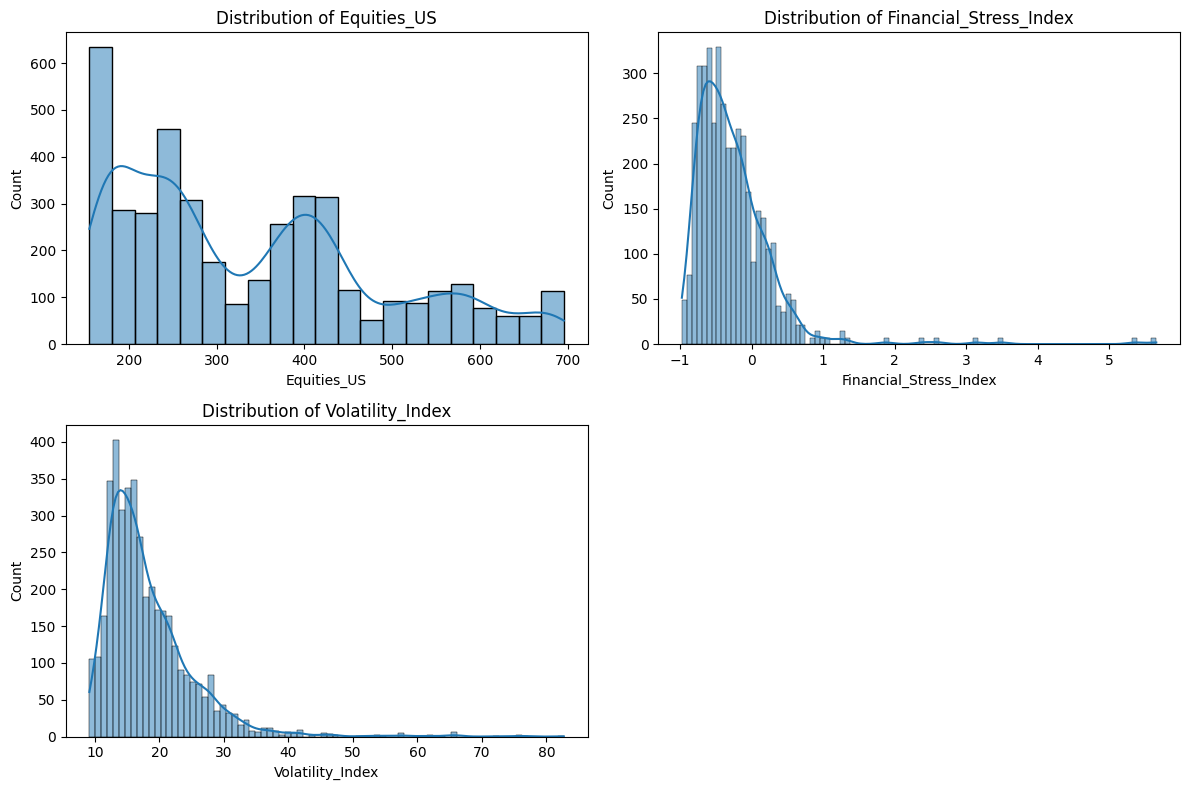

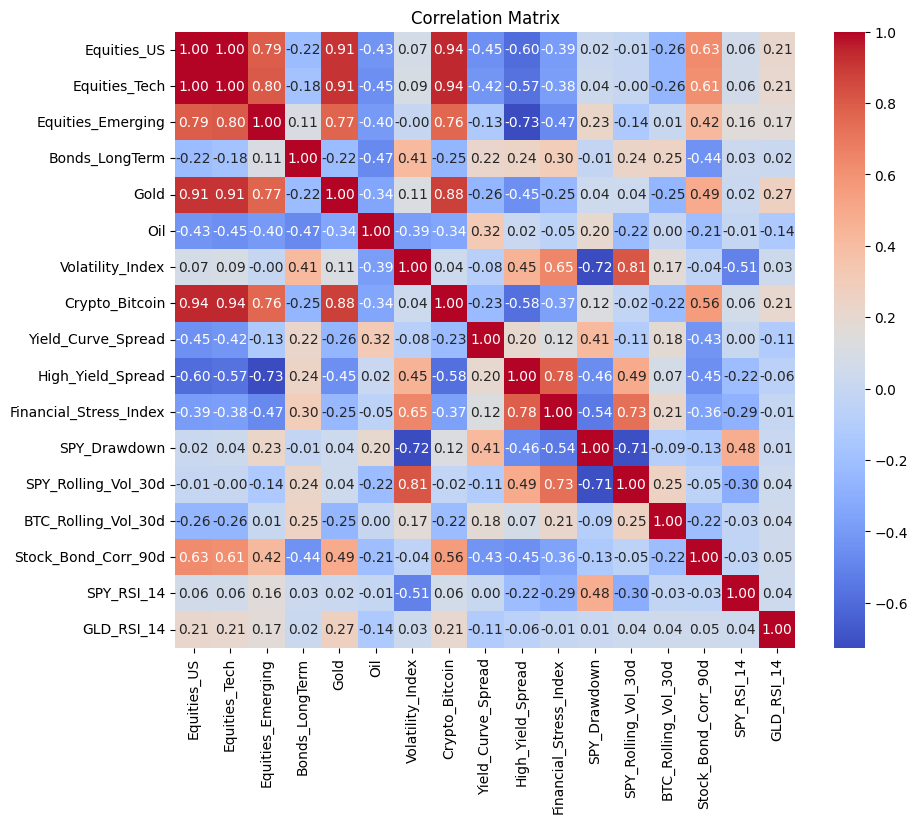

In [8]:
# Statistical distribution
print("\nStatistical Summary of Numerical Columns:")
print(df.describe().round(2))

# Distributions visualizations
plt.figure(figsize=(12, 8))
for i, col in enumerate(['Equities_US', 'Financial_Stress_Index', 'Volatility_Index'], 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

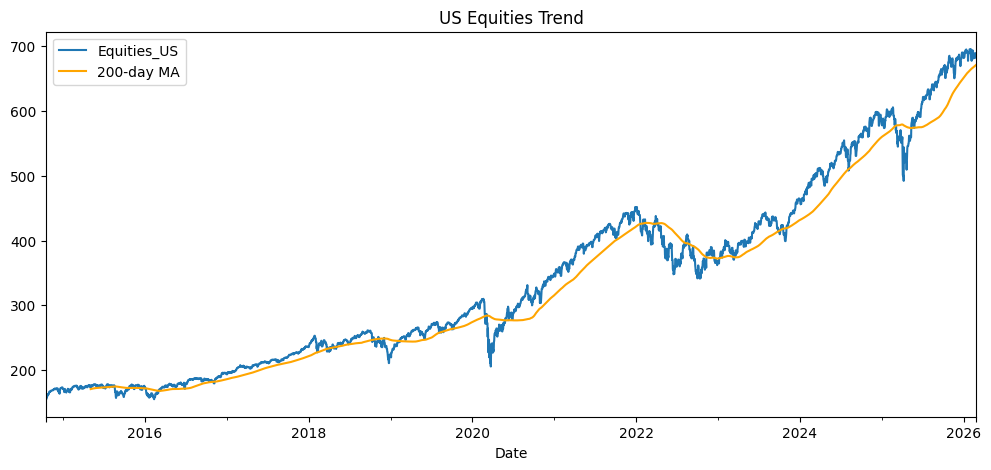

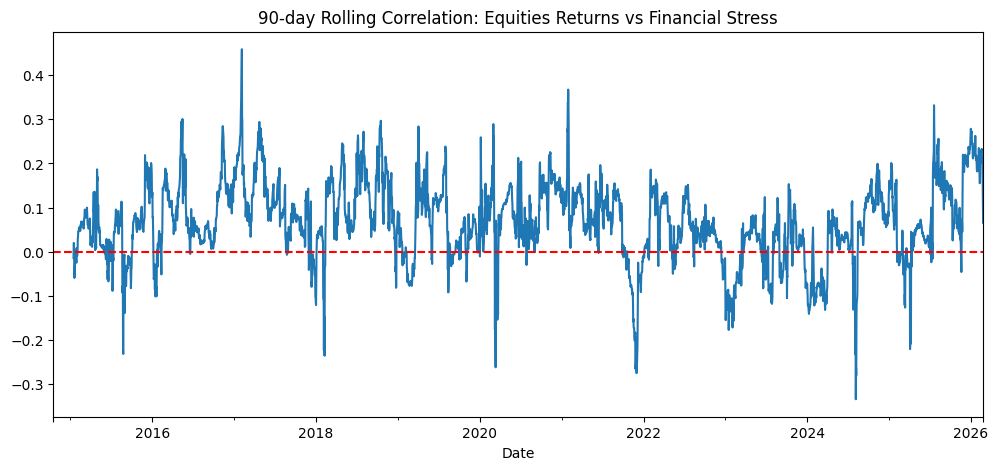

In [9]:
plt.figure(figsize=(12, 5))
df['Equities_US'].plot(label='Equities_US')
df['Equities_US'].rolling(200).mean().plot(label='200-day MA', color='orange')
plt.title("US Equities Trend")
plt.legend()
plt.show()

df['rolling_corr_90'] = df['Equities_US'].pct_change().rolling(90).corr(df['Financial_Stress_Index'])

plt.figure(figsize=(12, 5))
df['rolling_corr_90'].plot()
plt.axhline(0, color='red', ls='--')
plt.title("90-day Rolling Correlation: Equities Returns vs Financial Stress")
plt.show()

In [ ]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

print("="*60)
print("SEASONAL DECOMPOSITION")
print("="*60)

# Resample to monthly for clearer decomposition
df_monthly = df[['Equities_US']].resample('M').last().dropna()

# Decompose the series
decomposition = seasonal_decompose(df_monthly['Equities_US'], model='multiplicative', period=12)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("- Trend: Long-term direction of US equities")
print("- Seasonal: Repeating patterns (monthly/quarterly)")
print("- Residual: Random noise/unexplained variation")

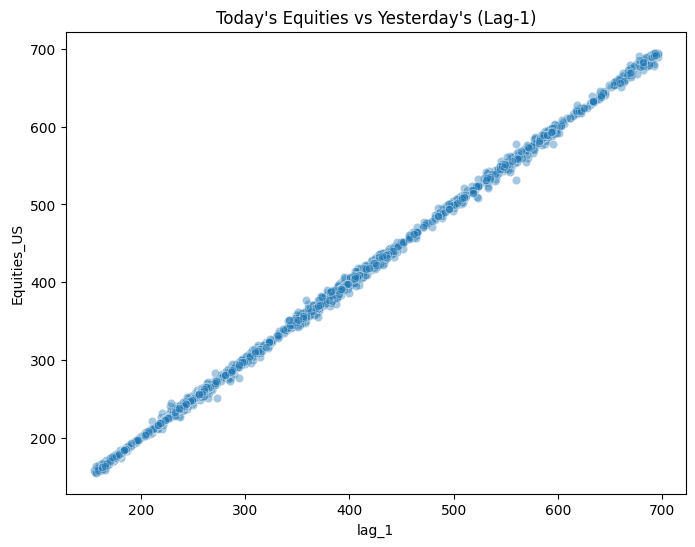

Lag-1 Correlation: 1.0


In [10]:
df['lag_1'] = df['Equities_US'].shift(1)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='lag_1', y='Equities_US', data=df.sample(3000), alpha=0.4)
plt.title("Today's Equities vs Yesterday's (Lag-1)")
plt.show()

print("Lag-1 Correlation:", df['Equities_US'].corr(df['lag_1']).round(3))

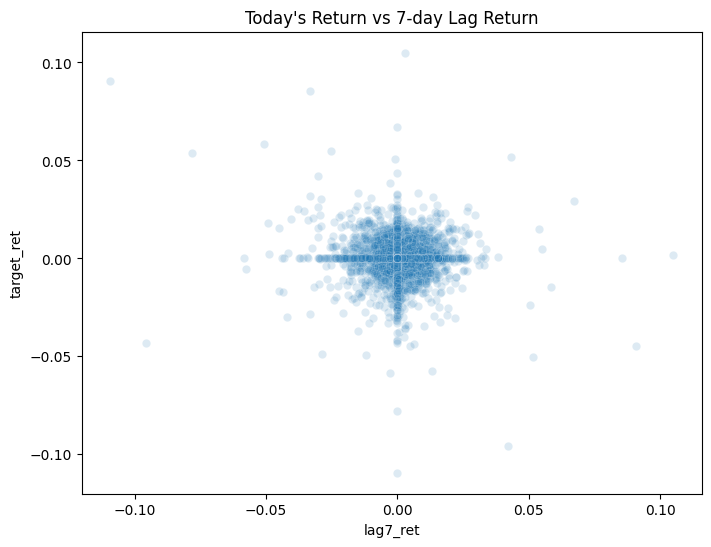

Lag-7 Return Correlation: -0.081


In [11]:
df['return'] = df['Equities_US'].pct_change()
df['lag7_ret'] = df['return'].shift(7)
df['target_ret'] = df['return'].shift(-1)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='lag7_ret', y='target_ret', data=df, alpha=0.15)
plt.title("Today's Return vs 7-day Lag Return")
plt.show()

print("Lag-7 Return Correlation:", df['lag7_ret'].corr(df['target_ret']).round(3))

In [12]:
# Returns & targets
df['return_1d'] = df['Equities_US'].pct_change()
df['lag_7'] = df['Equities_US'].shift(7)
df['rolling_corr_30'] = df['Equities_US'].rolling(30).corr(df['Financial_Stress_Index'])
df['target_reg'] = df['return_1d'].shift(-1)  # Next-day return
df['target_clf'] = (df['target_reg'] > 0).astype(int)  # 1=up, 0=down

df = df.dropna().reset_index()  # Reset index after drops

print("Shape after engineering:", df.shape)

Shape after engineering: (4059, 28)


In [13]:
# ────────────────────────────────────────────────────────────────
# Feature Engineering – must run BEFORE splitting and selecting features
# ────────────────────────────────────────────────────────────────

# Make sure these base columns exist and are numeric
required_cols = ['Equities_US', 'Financial_Stress_Index']
for col in required_cols:
    if col not in df.columns:
        print(f"Critical error: '{col}' column is missing!")
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create the missing features
df['lag_1'] = df['Equities_US'].shift(1)
df['lag_7'] = df['Equities_US'].shift(7)

df['ma_7']  = df['Equities_US'].rolling(window=7).mean()
df['vol_7'] = df['Equities_US'].rolling(window=7).std()          # or .pct_change().rolling(7).std() if you prefer return vol

df['rolling_corr_30'] = df['Equities_US'].rolling(window=30).corr(df['Financial_Stress_Index'])

df['return_1d']   = df['Equities_US'].pct_change()
df['target_reg']  = df['return_1d'].shift(-1)
df['target_clf']  = (df['target_reg'] > 0).astype(int)

df = df.dropna().reset_index(drop=True)

print("Columns after feature engineering:")
print(df.columns.tolist())

print("\nShape:", df.shape)
print("\nFirst 3 rows of important features:")
print(df[['Equities_US', 'lag_1', 'lag_7', 'ma_7', 'vol_7', 'rolling_corr_30', 'target_reg']].head(3))

Columns after feature engineering:
['Date', 'Equities_US', 'Equities_Tech', 'Equities_Emerging', 'Bonds_LongTerm', 'Gold', 'Oil', 'Volatility_Index', 'Crypto_Bitcoin', 'Yield_Curve_Spread', 'High_Yield_Spread', 'Financial_Stress_Index', 'SPY_Drawdown', 'SPY_Rolling_Vol_30d', 'BTC_Rolling_Vol_30d', 'Stock_Bond_Corr_90d', 'SPY_RSI_14', 'GLD_RSI_14', 'rolling_corr_90', 'lag_1', 'return', 'lag7_ret', 'target_ret', 'return_1d', 'lag_7', 'rolling_corr_30', 'target_reg', 'target_clf', 'ma_7', 'vol_7']

Shape: (4029, 30)

First 3 rows of important features:
   Equities_US       lag_1       lag_7        ma_7     vol_7  rolling_corr_30  \
0   174.201874  173.487732  170.689255  171.794885  1.560165        -0.648003   
1   174.201874  174.201874  170.689255  172.296688  1.703586        -0.669659   
2   174.201874  174.201874  170.689255  172.798490  1.668156        -0.695548   

   target_reg  
0         0.0  
1         0.0  
2         0.0  


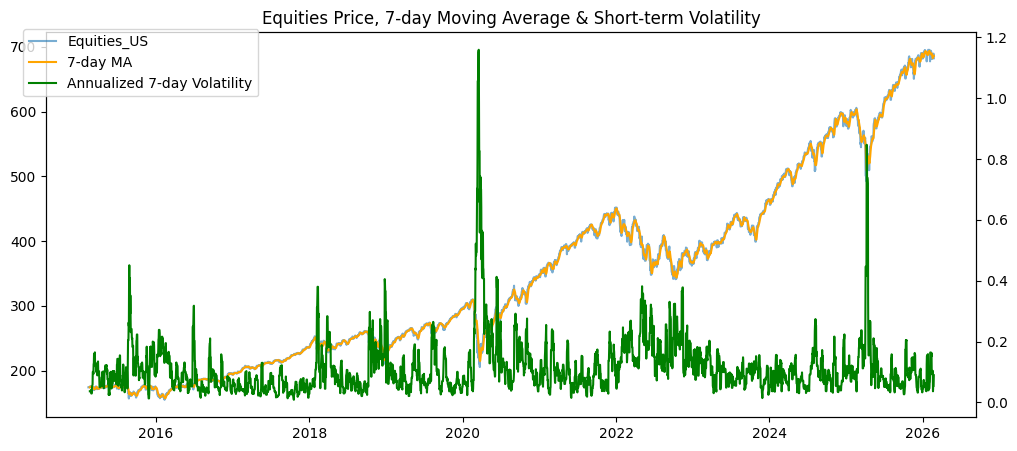

In [14]:
df['ma_7'] = df['Equities_US'].rolling(7).mean()
df['vol_7'] = df['Equities_US'].pct_change().rolling(7).std() * np.sqrt(252)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df['Date'], df['Equities_US'], label='Equities_US', alpha=0.6)
ax1.plot(df['Date'], df['ma_7'], label='7-day MA', color='orange')
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['vol_7'], label='Annualized 7-day Volatility', color='green')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title("Equities Price, 7-day Moving Average & Short-term Volatility")
plt.show()

In [15]:
features = [
    'lag_1', 'lag_7', 'ma_7', 'vol_7', 'rolling_corr_30',
    'Financial_Stress_Index', 'Volatility_Index',
    'Yield_Curve_Spread', 'High_Yield_Spread'
]

# Time-series split
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train[features]
X_test = test[features]
y_train_reg = train['target_reg']
y_test_reg = test['target_reg']
y_train_clf = train['target_clf']
y_test_clf = test['target_clf']

In [ ]:
# Enhanced Model Training with Cross-Validation and MAE
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print("="*60)
print("ENHANCED MODEL TRAINING WITH CROSS-VALIDATION")
print("="*60)

# Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

print(f"\nUsing TimeSeriesSplit with {tscv.n_splits} folds")
print("(Each fold uses all previous data for training, ensuring no data leakage)")

# Enhanced experiments with MAE and MAPE
results_reg_enhanced = []

for model_name, model_class, param_grid in [
    ("Linear Reg", LinearRegression, ParameterGrid({})),
    ("RF Reg", RandomForestRegressor, ParameterGrid({'n_estimators': [50, 200], 'max_depth': [8, 15]}))
]:
    for params in param_grid:
        # Cross-validation scores
        cv_rmse, cv_mae = [], []
        
        for train_idx, val_idx in tscv.split(X_train_clean):
            X_tr, X_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
            y_tr, y_val = y_train_reg_clean.iloc[train_idx], y_train_reg_clean.iloc[val_idx]
            
            if model_name == "Linear Reg":
                model = model_class(**params)
            else:
                model = model_class(**params, random_state=42)
            
            model.fit(X_tr, y_tr)
            pred = model.predict(X_val)
            cv_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
            cv_mae.append(mean_absolute_error(y_val, pred))
        
        # Final test prediction
        if model_name == "Linear Reg":
            model = model_class(**params)
        else:
            model = model_class(**params, random_state=42)
        model.fit(X_train_clean, y_train_reg_clean)
        pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
        r2 = r2_score(y_test_reg, pred)
        mae = mean_absolute_error(y_test_reg, pred)
        mape = mean_absolute_percentage_error(y_test_reg, pred) * 100
        
        results_reg_enhanced.append({
            'Model': model_name, 
            'Params': str(params), 
            'CV_RMSE': round(np.mean(cv_rmse), 6),
            'CV_MAE': round(np.mean(cv_mae), 6),
            'Test_RMSE': round(rmse, 6),
            'Test_MAE': round(mae, 6),
            'Test_MAPE%': round(mape, 2),
            'R²': round(r2, 4)
        })

print("\nEnhanced Regression Experiments (with Cross-Validation):")
results_df = pd.DataFrame(results_reg_enhanced)
print(results_df.to_string(index=False))

In [17]:
# Experiments
# First, ensure X_train and X_test have no NaN values
X_train_clean = X_train.dropna()
y_train_reg_clean = y_train_reg.loc[X_train_clean.index]
y_train_clf_clean = y_train_clf.loc[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_reg_clean = y_test_reg.loc[X_test_clean.index]
y_test_clf_clean = y_test_clf.loc[X_test_clean.index]

results_reg = []
for model_name, model_class, param_grid in [
    ("Linear Reg", LinearRegression, ParameterGrid({})),
    ("RF Reg", RandomForestRegressor, ParameterGrid({'n_estimators': [50, 200], 'max_depth': [8, 15]}))
]:
    for params in param_grid:
        # Conditionally add random_state, as LinearRegression does not accept it
        if model_name == "Linear Reg":
            model = model_class(**params)
        else:
            model = model_class(**params, random_state=42)
        model.fit(X_train_clean, y_train_reg_clean)
        pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
        r2 = r2_score(y_test_reg, pred)
        results_reg.append(
            {'Model': model_name, 'Params': params, 'RMSE': round(rmse, 6), 'R²': round(r2, 4)}
        )

print("Regression Experiments:")
print(pd.DataFrame(results_reg).sort_values('RMSE'))

Regression Experiments:
        Model                                  Params      RMSE      R²
0  Linear Reg                                      {}  0.008501 -0.0417
2      RF Reg   {'max_depth': 8, 'n_estimators': 200}  0.009045 -0.1794
1      RF Reg    {'max_depth': 8, 'n_estimators': 50}  0.009162 -0.2101
4      RF Reg  {'max_depth': 15, 'n_estimators': 200}  0.011096 -0.7747
3      RF Reg   {'max_depth': 15, 'n_estimators': 50}  0.012358 -1.2014


In [19]:
# Similar for classification
results_clf = []
for model_name, model_class, param_grid in [
    ("Logistic", LogisticRegression, ParameterGrid({'max_iter': [1000]})),
    ("RF Clf", RandomForestClassifier, ParameterGrid({'n_estimators': [50, 200], 'max_depth': [8, 15]}))
]:
    for params in param_grid:
        # LogisticRegression and RandomForestClassifier both accept random_state
        model = model_class(**params, random_state=42)
        model.fit(X_train_clean, y_train_clf_clean)
        pred = model.predict(X_test_clean)
        acc = accuracy_score(y_test_clf_clean, pred)
        results_clf.append({
            'Model': model_name, 'Params': params, 'Accuracy': round(acc, 4)
        })

print("\nClassification Experiments:")
print(pd.DataFrame(results_clf).sort_values('Accuracy', ascending=False))


Classification Experiments:
      Model                                  Params  Accuracy
0  Logistic                      {'max_iter': 1000}    0.6042
2    RF Clf   {'max_depth': 8, 'n_estimators': 200}    0.5769
1    RF Clf    {'max_depth': 8, 'n_estimators': 50}    0.5509
4    RF Clf  {'max_depth': 15, 'n_estimators': 200}    0.5074
3    RF Clf   {'max_depth': 15, 'n_estimators': 50}    0.4888


In [ ]:
# Feature Importance Analysis
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Train best model on full training data
best_rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
best_rf.fit(X_train, y_train_reg)

# Get feature importances
importances = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances (Random Forest):")
print(importances.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'], importances['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("- Higher importance = more predictive power")
print("- Lag features capture momentum effects")
print("- Volatility measures risk exposure")

In [20]:
# Best model example: Use RF Reg with best params for backtest
best_rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
best_rf_reg.fit(X_train, y_train_reg)

# Naive baselines for fair comparison

# Regression: always predict the mean of training returns
naive_reg_pred = np.full_like(y_test_reg, y_train_reg.mean())
naive_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, naive_reg_pred))
naive_reg_r2   = r2_score(y_test_reg, naive_reg_pred)

print("\nNaive Baseline (mean predictor) - Regression:")
print(f"RMSE: {naive_reg_rmse:.6f}")
print(f"R²:   {naive_reg_r2:.4f}")

# Classification: always predict the majority class from training
majority_class = y_train_clf.mode()[0]
naive_clf_pred = np.full_like(y_test_clf, majority_class)
naive_clf_acc  = accuracy_score(y_test_clf, naive_clf_pred)

print("\nNaive Baseline (majority class) - Classification:")
print(f"Accuracy: {naive_clf_acc:.4f}")


Naive Baseline (mean predictor) - Regression:
RMSE: 0.008332
R²:   -0.0007

Naive Baseline (majority class) - Classification:
Accuracy: 0.6030


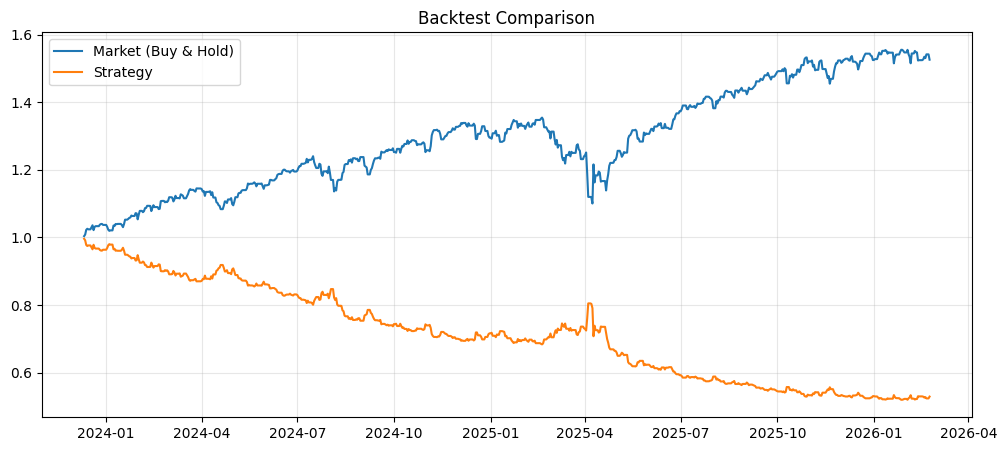

Market Total Return:   52.56%
Strategy Total Return: -47.06%
Market Sharpe:         1.06
Strategy Sharpe:       -1.44


In [21]:
test = test.copy()
test['pred_return'] = best_rf_reg.predict(X_test)
test['position'] = np.sign(test['pred_return'])
test['strategy_return'] = test['position'] * test['return_1d']

test['cum_market']   = (1 + test['return_1d']).cumprod()
test['cum_strategy'] = (1 + test['strategy_return']).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(test['Date'], test['cum_market'], label='Market (Buy & Hold)')
plt.plot(test['Date'], test['cum_strategy'], label='Strategy')
plt.title('Backtest Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def sharpe(returns):
    return np.sqrt(252) * returns.mean() / returns.std() if returns.std() != 0 else 0

print("Market Total Return:   {:.2%}".format(test['cum_market'].iloc[-1] - 1))
print("Strategy Total Return: {:.2%}".format(test['cum_strategy'].iloc[-1] - 1))
print("Market Sharpe:         {:.2f}".format(sharpe(test['return_1d'])))
print("Strategy Sharpe:       {:.2f}".format(sharpe(test['strategy_return'])))

## Export Model Results and Processed Data for Database Inserts
This section exports the processed test set and model experiment results to the `data/for_db_inserts` folder for use in database population (SQL/MongoDB), as required by the rubric.

In [ ]:
# Export processed test set for database inserts (CSV and JSON)
test_export = test[['Date', 'return_1d', 'pred_return', 'position', 'strategy_return', 'cum_market', 'cum_strategy']].copy()

# Save as CSV (for SQL)
test_export.to_csv('data/for_db_inserts/test_results.csv', index=False)

# Save as JSON (for MongoDB)
test_export.to_json('data/for_db_inserts/test_results.json', orient='records', date_format='iso')

print('Exported test results to data/for_db_inserts/test_results.csv and test_results.json')

In [ ]:
# Export model experiment results for database inserts
import json

with open('data/for_db_inserts/regression_results.json', 'w') as f:
    json.dump(results_reg, f, indent=2)

with open('data/for_db_inserts/classification_results.json', 'w') as f:
    json.dump(results_clf, f, indent=2)

print('Exported model experiment results to data/for_db_inserts/regression_results.json and classification_results.json')